## Import thư viện và nạp dữ liệu

In [4]:
# Cell 1: Nạp thư viện và Đọc dữ liệu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Tải dữ liệu từ đường dẫn được chỉ định
data_path = "../../DATA/diabetes.csv"
df = pd.read_csv(data_path)

print("Kích thước dữ liệu gốc:", df.shape)
display(df.head())

Kích thước dữ liệu gốc: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Phân tích dữ liệu khám phá (EDA)

Thông tin dữ liệu:

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB

Phân bố nhãn bệnh tiểu đường (Target):
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


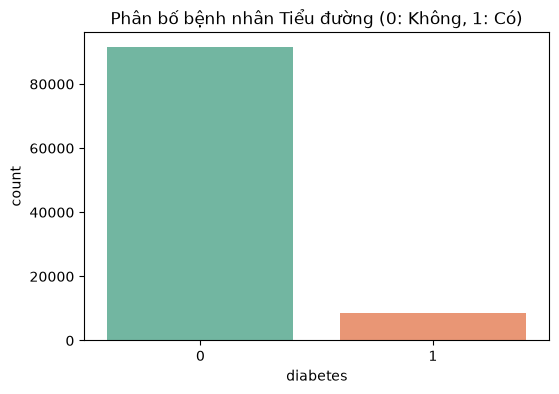

In [5]:
# Cell 2: EDA - Kiểm tra phân bố và kiểu dữ liệu
print("Thông tin dữ liệu:\n")
df.info()

print("\nPhân bố nhãn bệnh tiểu đường (Target):")
print(df['diabetes'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
# Cập nhật: Thêm hue='diabetes' và legend=False theo chuẩn mới của Seaborn
sns.countplot(x='diabetes', data=df, hue='diabetes', palette='Set2', legend=False)
plt.title("Phân bố bệnh nhân Tiểu đường (0: Không, 1: Có)")
plt.show()

## Tiền xử lý và định dạng dữ liệu cho 1D CNN

In [6]:
# Cell 3: Mã hóa Categorical, Chuẩn hóa và Reshape
# 1. Mã hóa các biến phân loại (gender, smoking_history) thành số nguyên
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])

# 2. Tách đặc trưng (X) và nhãn (y) - Đảm bảo chính xác 8 đặc trưng
X = df.drop('diabetes', axis=1).values
y = df['diabetes'].values

# 3. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Chuẩn hóa dữ liệu (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Reshape cho CNN 1D: Từ (N, 8) chuyển thành (N, 1, 8) cho kênh PyTorch/NumPy
# Hoặc (N, 8, 1) cho Keras. Ở đây chuẩn bị cho cấu trúc cơ sở:
X_train_cnn = X_train_scaled.reshape(-1, 1, 8)
X_test_cnn = X_test_scaled.reshape(-1, 1, 8)
y_train_cnn = y_train.reshape(-1, 1)

print("Shape đầu vào Train (CNN):", X_train_cnn.shape) # Output mong đợi: (Số mẫu, 1, 8)

Shape đầu vào Train (CNN): (80000, 1, 8)


## CNN from Scratch - Các hàm toán học cốt lõi

In [7]:
# Cell 4: Định nghĩa Tích chập và Hàm kích hoạt thủ công bằng NumPy
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def conv1d_forward(X, W, b):
    N, C_in, L_in = X.shape
    C_out, _, K = W.shape
    L_out = L_in - K + 1
    
    Z = np.zeros((N, C_out, L_out))
    
    # Trượt kernel qua từng vị trí
    for n in range(N):
        for c_out in range(C_out):
            for i in range(L_out):
                Z[n, c_out, i] = np.sum(X[n, :, i:i+K] * W[c_out, :, :]) + b[c_out]
    return Z

## CNN from Scratch - Lan truyền tiến (Forward Pass Demo)

In [8]:
# Cell 5: Khởi tạo trọng số và chạy lan truyền tiến (Demo)
np.random.seed(42)

# Khởi tạo tham số cho Conv1D: 1 Filter, Kernel_size = 3
W_conv = np.random.randn(1, 1, 3) * 0.1
b_conv = np.zeros(1)

# Tính toán chiều dài Output sau Conv1D: 8 - 3 + 1 = 6
W_dense = np.random.randn(6, 1) * 0.1
b_dense = np.zeros(1)

# Forward pass
Z1 = conv1d_forward(X_train_cnn[:100], W_conv, b_conv) # Chạy thử trên 100 mẫu để tiết kiệm thời gian
A1 = relu(Z1)
A1_flat = A1.reshape(100, -1)
Z2 = np.dot(A1_flat, W_dense) + b_dense
predictions = sigmoid(Z2)

print("Demo NumPy CNN Forward Pass thành công!")
print("Dự đoán 5 mẫu đầu tiên:\n", predictions[:5].flatten())

Demo NumPy CNN Forward Pass thành công!
Dự đoán 5 mẫu đầu tiên:
 [0.50639614 0.49970168 0.49932312 0.5001069  0.5       ]


## Triển khai mô hình bằng PyTorch

In [15]:
# Cell 6: PyTorch 1D CNN Implementation
import torch
import torch.nn as nn
import torch.optim as optim

class PyTorchCNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        # Sau Conv1D(8, k=3) -> L = 6
        # Sau MaxPool1D(k=2) -> L = 3
        # Flatten: 16 channels * 3 = 48
        self.fc = nn.Linear(48, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = torch.flatten(x, 1)
        x = self.sigmoid(self.fc(x))
        return x

model_pt = PyTorchCNN1D()
print(model_pt)

PyTorchCNN1D(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=48, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Triển khai mô hình bằng TensorFlow/Keras

In [13]:
# Cell 7: Triển khai mô hình Keras (Sử dụng PyTorch Backend, chuẩn cú pháp Keras 3)
import os
os.environ["KERAS_BACKEND"] = "torch" 

import keras
from keras import layers, models, Input

# Định dạng dữ liệu cho Keras: (Batch, Length, Channels)
X_train_keras = X_train_scaled.reshape(-1, 8, 1)
X_test_keras = X_test_scaled.reshape(-1, 8, 1)

# Xây dựng kiến trúc theo chuẩn Keras 3 (Tách riêng Input layer)
model_keras = models.Sequential([
    Input(shape=(8, 1)), 
    layers.Conv1D(filters=16, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
])

model_keras.compile(optimizer='adam', 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

print("Cấu trúc mạng Keras:")
model_keras.summary()

# Huấn luyện mô hình
history = model_keras.fit(X_train_keras, y_train, 
                       epochs=10,             # Giảm số Epoch xuống 10 (đủ để thấy hội tụ)
                       batch_size=512,        # Tăng batch_size lên gấp 16 lần để tăng tốc CPU
                       validation_split=0.2, 
                       verbose=1)

Cấu trúc mạng Keras:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 6, 16)               │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 3, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9063 - loss: 0.3785 - val_accuracy: 0.9144 - val_loss: 0.2530
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9222 - loss: 0.2109 - val_accuracy: 0.9272 - val_loss: 0.1875
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9368 - loss: 0.1693 - val_accuracy: 0.9408 - val_loss: 0.1595
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9479 - loss: 0.1468 - val_accuracy: 0.9511 - val_loss: 0.1415
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9542 - loss: 0.1328 - val_accuracy: 0.9553 - val_loss: 0.1302
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9579 - loss: 0.1243 - val_accuracy: 0.9578 - val_loss: 0.1236
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9594 - loss: 0.1194 - val_accuracy: 0.9587 - val_loss: 0.1197
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9603 - loss: 0.1166 - val_accuracy: 0.

## Đánh giá bằng các độ đo phân loại

In [17]:
# Cell 8: Đánh giá mô hình Keras trên tập Test
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Sử dụng đúng tên biến model_keras và X_test_keras từ Cell 7
y_pred_prob = model_keras.predict(X_test_keras)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\n--- BÁO CÁO PHÂN LOẠI (Classification Report) ---")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy tổng thể: {acc * 100:.2f}%")

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- BÁO CÁO PHÂN LOẠI (Classification Report) ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.88      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Accuracy tổng thể: 96.12%


## Biểu đồ phân tích động học huấn luyện

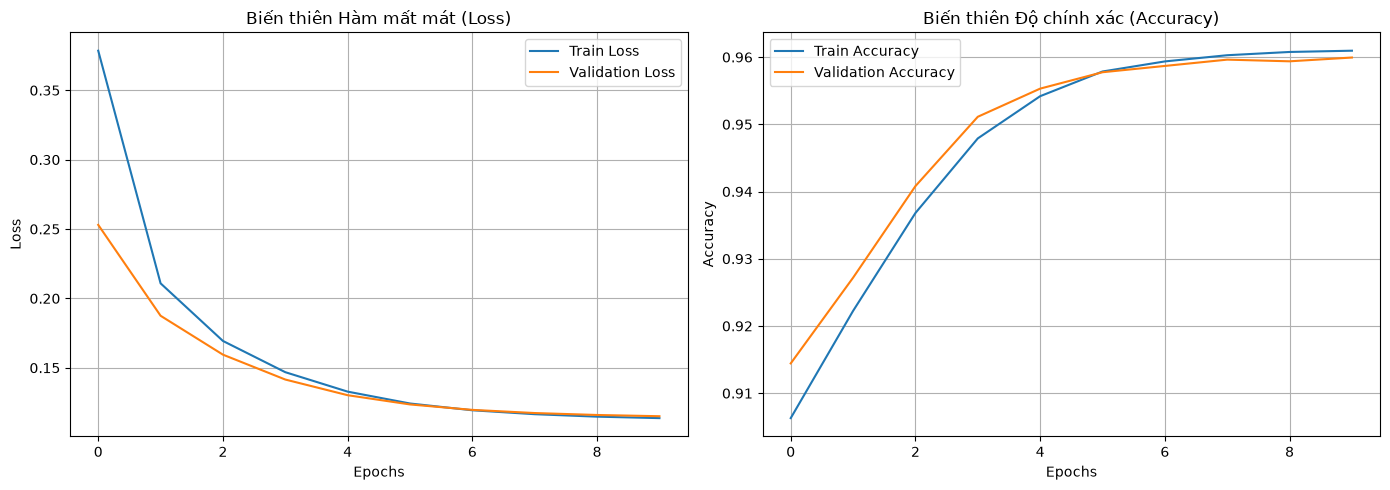

In [18]:
# Cell 9: Trực quan hóa Đường cong học tập (Loss & Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị Loss
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Biến thiên Hàm mất mát (Loss)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Đồ thị Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Biến thiên Độ chính xác (Accuracy)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Ma trận nhầm lẫn (Confusion Matrix)

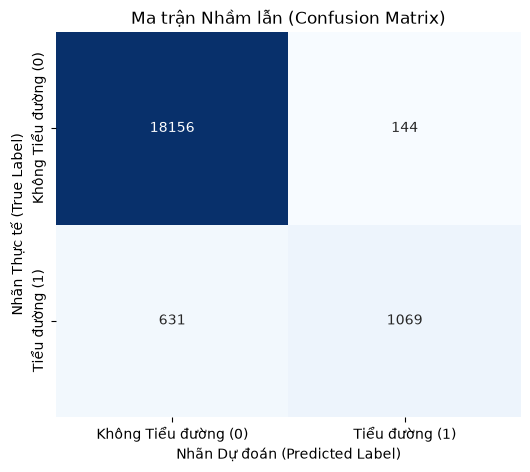

In [19]:
# Cell 10: Trực quan hóa Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Không Tiểu đường (0)', 'Tiểu đường (1)'],
            yticklabels=['Không Tiểu đường (0)', 'Tiểu đường (1)'])
plt.title('Ma trận Nhầm lẫn (Confusion Matrix)')
plt.xlabel('Nhãn Dự đoán (Predicted Label)')
plt.ylabel('Nhãn Thực tế (True Label)')
plt.show()